# RNN for NLP — Forward & Backward Propagation, from scratch

**Programming Hero · Class 01 companion notebook**

This notebook turns the lecture
[`Class01_RNN_for_NLP.html`](./Class01_RNN_for_NLP.html) into runnable code. We
build a **character-level Recurrent Neural Network entirely in NumPy** and use it
to *show* the ideas in action on real text:

| Lecture topic | Where it appears here |
|---|---|
| Why RNNs for NLP (sequences, shared weights) | §1 Data, §2 The RNN cell |
| The RNN cell &amp; equations | §2 |
| **Forward propagation** | §3 |
| **Backward propagation through time (BPTT)** | §4 |
| Gradient checking (is our math right?) | §5 |
| Generating / sampling text | §6 |
| Training the network | §7 |
| Vanishing gradients | §9 |
| From scratch → PyTorch `nn.RNN` | §10 |

We deliberately use **plain NumPy** (no autograd) so that every line of the
forward and backward pass is explicit — that is the whole point of the lecture.

### The task: character-level language modelling
Given a few characters of text, predict the **next character**. This is the
simplest possible NLP task that still needs *memory of the past*, which is
exactly what an RNN provides through its hidden state \(h_t\).


## 0. Environment & packages

This notebook was developed and verified with the versions below. Uncomment the
`pip install` line to recreate the environment.

```bash
pip install numpy==2.4.3 matplotlib==3.10.8 requests==2.32.5
```

All three are lightweight, pure-CPU packages — no GPU or deep-learning framework
is required because we implement the RNN ourselves.


In [1]:
# %pip install numpy==2.4.3 matplotlib==3.10.8 requests==2.32.5

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

try:
    import requests
    REQUESTS_VER = requests.__version__
except ImportError:
    requests = None
    REQUESTS_VER = "not installed (offline fallback will be used)"

print("python    :", sys.version.split()[0])
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("requests  :", REQUESTS_VER)

np.random.seed(1)  # reproducibility

python    : 3.11.14
numpy     : 2.4.3
matplotlib: 3.10.8
requests  : 2.32.5


## 1. Get a small text corpus (RNN for NLP)

NLP models learn from text. We grab a small slice of the classic
**tiny-shakespeare** corpus. If the network is unavailable, we fall back to a
short embedded snippet so the notebook always runs.

**Tokenisation.** We use the simplest possible tokens — *individual
characters*. The model therefore has a small vocabulary (the set of unique
characters) and learns spelling, word boundaries and punctuation directly from
data.


In [2]:
FALLBACK_TEXT = (
    "First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
    "All:\nSpeak, speak.\n\n"
    "First Citizen:\nYou are all resolved rather to die than to famish?\n\n"
    "All:\nResolved. resolved.\n\n"
    "First Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n"
) * 40


def load_text(n_chars=50000):
    """Fetch tiny-shakespeare; fall back to an embedded snippet if offline."""
    url = ("https://raw.githubusercontent.com/karpathy/char-rnn/"
           "master/data/tinyshakespeare/input.txt")
    if requests is not None:
        try:
            text = requests.get(url, timeout=10).text
            return text[:n_chars], "tiny-shakespeare (downloaded)"
        except Exception as exc:
            return FALLBACK_TEXT[:n_chars], f"offline fallback ({type(exc).__name__})"
    return FALLBACK_TEXT[:n_chars], "offline fallback (requests missing)"


text, source = load_text(n_chars=200000)
print("source     :", source)
print("length     :", len(text), "characters")
print("-" * 60)
print(text[:250])

source     : tiny-shakespeare (downloaded)
length     : 200000 characters
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [3]:
# Build the vocabulary: a bijection between characters and integer ids
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}   # char  -> id
itos = {i: c for c, i in stoi.items()}       # id    -> char

# Encode the whole corpus as a list of integer ids
data_ix = [stoi[c] for c in text]

print("vocab size :", vocab_size)
print("characters :", "".join(chars).replace("\n", "\\n"))
print("example    :", text[:20], "->", data_ix[:20])

vocab size : 62
characters : \n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYZabcdefghijklmnopqrstuvwxyz
example    : First Citizen:
Befor -> [16, 44, 53, 54, 55, 1, 13, 44, 55, 44, 61, 40, 49, 8, 0, 12, 40, 41, 50, 53]


## 2. The RNN cell & parameters

A vanilla RNN keeps a **hidden state** \(h_t\) that summarises everything seen so
far. At each step it reads input \(x_t\) (a one-hot character vector) and updates:

\[
h_t = \tanh\!\big(W_{xh}\,x_t + W_{hh}\,h_{t-1} + b_h\big)
\]
\[
\hat y_t = \mathrm{softmax}\!\big(W_{hy}\,h_t + b_y\big)
\]

The **same** weight matrices are reused at every time step (*weight sharing*),
which is why an RNN can handle sequences of any length with a fixed number of
parameters.

| Parameter | Shape | Role |
|---|---|---|
| `Wxh` | (H, V) | input → hidden |
| `Whh` | (H, H) | hidden → hidden (the *recurrent* connection) |
| `Why` | (V, H) | hidden → output logits |
| `bh`  | (H, 1) | hidden bias |
| `by`  | (V, 1) | output bias |

where `V = vocab_size` and `H = hidden_size`.


In [4]:
def init_params(vocab_size, hidden_size):
    return {
        "Wxh": np.random.randn(hidden_size, vocab_size) * 0.01,
        "Whh": np.random.randn(hidden_size, hidden_size) * 0.01,
        "Why": np.random.randn(vocab_size, hidden_size) * 0.01,
        "bh":  np.zeros((hidden_size, 1)),
        "by":  np.zeros((vocab_size, 1)),
    }


def softmax(z):
    """Numerically stable softmax for a column vector."""
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)


hidden_size = 100
seq_len = 25                       # how many steps we unroll for one BPTT update
params = init_params(vocab_size, hidden_size)

for k, v in params.items():
    print(f"{k:4s} shape {v.shape}")

Wxh  shape (100, 62)
Whh  shape (100, 100)
Why  shape (62, 100)
bh   shape (100, 1)
by   shape (62, 1)


## 3. Forward propagation

We **unroll** the RNN over a window of `seq_len` characters. For each step `t`
we build the one-hot input, update the hidden state, produce a probability
distribution over the next character, and accumulate the **cross-entropy loss**

\[
L = -\sum_t \log \hat y_t[\text{target}_t].
\]

We keep a `cache` of `(xs, hs, ps)` for every time step — backprop needs these
intermediate values.


In [5]:
def rnn_forward(inputs, targets, hprev, p):
    """Forward pass over one sequence window.

    inputs, targets : lists of int ids (targets = inputs shifted by one)
    hprev           : (H,1) hidden state carried in from the previous window
    returns         : loss, cache, last hidden state
    """
    xs, hs, ps = {}, {}, {}
    hs[-1] = np.copy(hprev)
    loss = 0.0
    for t in range(len(inputs)):
        xs[t] = np.zeros((vocab_size, 1))
        xs[t][inputs[t]] = 1                                    # one-hot input
        hs[t] = np.tanh(p["Wxh"] @ xs[t] + p["Whh"] @ hs[t-1] + p["bh"])
        ps[t] = softmax(p["Why"] @ hs[t] + p["by"])             # next-char probs
        loss += -np.log(ps[t][targets[t], 0] + 1e-12)           # cross-entropy
    cache = (xs, hs, ps)
    return loss, cache, hs[len(inputs) - 1]


# Quick sanity check on the first window
inputs  = data_ix[:seq_len]
targets = data_ix[1:seq_len + 1]
h0 = np.zeros((hidden_size, 1))

loss, cache, hlast = rnn_forward(inputs, targets, h0, params)
print(f"loss on first window     : {loss:.3f}")
print(f"expected loss at random  : {-np.log(1/vocab_size) * seq_len:.3f}")
print("(an untrained model should be close to the random baseline)")

loss on first window     : 103.179
expected loss at random  : 103.178
(an untrained model should be close to the random baseline)


## 4. Backward propagation through time (BPTT)

To train, we need \(\partial L / \partial \theta\) for every parameter
\(\theta\). Because the **same** weights are used at every step, gradients from
all time steps are **summed**. We walk **backwards** through the unrolled graph,
carrying a gradient `dhnext` that flows from step `t+1` into step `t`.

For each step (right → left):

\[
\frac{\partial L}{\partial \text{logits}_t} = \hat y_t - \text{onehot}(\text{target}_t)
\]
\[
\frac{\partial L}{\partial h_t} = W_{hy}^\top \,\frac{\partial L}{\partial \text{logits}_t} + \underbrace{\frac{\partial L}{\partial h_{t+1}}\;\text{(via } W_{hh}\text{)}}_{\text{dhnext}}
\]
\[
\frac{\partial L}{\partial z_t} = \big(1 - h_t^2\big)\odot \frac{\partial L}{\partial h_t}\quad(\text{the } \tanh' \text{ term})
\]

The repeated multiplication by \(W_{hh}^\top\) and \((1-h^2)\) is *exactly* what
later causes **vanishing / exploding gradients** (§9). We clip gradients to
\([-5, 5]\) to keep training stable.


In [6]:
def rnn_backward(inputs, targets, cache, p):
    """Backprop through time over one window. Returns the gradient dict."""
    xs, hs, ps = cache
    grads = {k: np.zeros_like(v) for k, v in p.items()}
    dhnext = np.zeros_like(hs[0])
    for t in reversed(range(len(inputs))):
        dy = np.copy(ps[t])
        dy[targets[t]] -= 1                                     # softmax+CE grad
        grads["Why"] += dy @ hs[t].T
        grads["by"]  += dy
        dh = p["Why"].T @ dy + dhnext                           # total grad into h_t
        dz = (1 - hs[t] ** 2) * dh                              # back through tanh
        grads["bh"]  += dz
        grads["Wxh"] += dz @ xs[t].T
        grads["Whh"] += dz @ hs[t-1].T
        dhnext = p["Whh"].T @ dz                                # pass back one step
    for g in grads.values():
        np.clip(g, -5, 5, out=g)                                # guard against blow-up
    return grads


def loss_and_grads(inputs, targets, hprev, p):
    """Convenience wrapper: forward then backward."""
    loss, cache, hlast = rnn_forward(inputs, targets, hprev, p)
    grads = rnn_backward(inputs, targets, cache, p)
    return loss, grads, hlast


loss, grads, _ = loss_and_grads(inputs, targets, h0, params)
print("gradient shapes (match the parameters):")
for k, g in grads.items():
    print(f"  d{k:4s} {g.shape}   |max|={np.abs(g).max():.4f}")

gradient shapes (match the parameters):
  dWxh  (100, 62)   |max|=0.0761
  dWhh  (100, 100)   |max|=0.0026
  dWhy  (62, 100)   |max|=0.0554
  dbh   (100, 1)   |max|=0.1846
  dby   (62, 1)   |max|=3.5966


## 5. Gradient check — is our backprop correct?

Hand-derived gradients are error-prone, so we verify them numerically. For a few
random parameters we compare the analytic gradient with the **central finite
difference**

\[
\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}.
\]

A relative error below \(10^{-4}\) means our BPTT is implemented correctly.


In [7]:
def gradient_check(inputs, targets, hprev, p, n_checks=8, eps=1e-5):
    _, grads, _ = loss_and_grads(inputs, targets, hprev, p)
    rng = np.random.default_rng(0)
    rel_errors = []
    for name in ["Wxh", "Whh", "Why", "bh", "by"]:
        W = p[name]
        for _ in range(n_checks):
            idx = tuple(rng.integers(0, s) for s in W.shape)
            orig = W[idx]
            W[idx] = orig + eps
            l1, _, _ = rnn_forward(inputs, targets, hprev, p)
            W[idx] = orig - eps
            l2, _, _ = rnn_forward(inputs, targets, hprev, p)
            W[idx] = orig
            num = (l1 - l2) / (2 * eps)        # numerical gradient
            ana = grads[name][idx]             # analytic gradient
            rel_errors.append(abs(num - ana) / max(1e-9, abs(num) + abs(ana)))
    return float(np.max(rel_errors)), float(np.mean(rel_errors))


mx, mean = gradient_check(inputs, targets, h0, init_params(vocab_size, hidden_size))
print(f"max  relative error : {mx:.2e}")
print(f"mean relative error : {mean:.2e}")
print("PASS ✓" if mx < 1e-4 else "FAIL ✗")

max  relative error : 5.55e-05
mean relative error : 1.99e-06
PASS ✓


## 6. Sampling — generating text with the forward pass

To *see* what the model has learned we feed a seed character, take the output
distribution, sample a character from it, feed that back in, and repeat. This
uses **only the forward pass** — no targets, no gradients.


In [8]:
def sample(h, seed_ix, n, p):
    """Generate n characters starting from seed_ix. Returns a list of ids."""
    x = np.zeros((vocab_size, 1))
    x[seed_ix] = 1
    ixes = []
    for _ in range(n):
        h = np.tanh(p["Wxh"] @ x + p["Whh"] @ h + p["bh"])
        prob = softmax(p["Why"] @ h + p["by"]).ravel()
        ix = np.random.choice(range(vocab_size), p=prob)
        x = np.zeros((vocab_size, 1)); x[ix] = 1
        ixes.append(ix)
    return ixes


def decode(ixes):
    return "".join(itos[i] for i in ixes)


print("BEFORE training (random weights) — pure gibberish:\n")
print(decode(sample(np.zeros((hidden_size, 1)), data_ix[0], 250, params)))

BEFORE training (random weights) — pure gibberish:

NRCksPsi:,Ub:q:rEGv,FqI':fZ:HlT
n;:Qfsjo;u qMTGqt g:JElto;UROSL'zeqEoetPPzoz
x'p!GDvNBsOFD:caywH'WHF,i&aBWvltCWOnW;jHkhbnF oQ'PFN uxmf'THx&Ww.ilbFmNKtydehtYh!FUEsRQqGaU.cIIfkEB-QQdwqHRtkA&'FirkO Z&LDqP hfmZJcqSZuGUcro Qghm&s'auqGMGPDKwynP?m'PosGBqZOL


## 7. Training with Adagrad

We slide a window of `seq_len` characters across the corpus. For each window we
run forward + BPTT, then update parameters with **Adagrad** (a per-parameter
adaptive learning rate that works well for this toy model). The hidden state is
**carried across windows** so the network sees long-range context.

We track a *smoothed* loss so the curve is readable.


In [9]:
def train(data_ix, p, iters=6000, lr=0.1, log_every=1000):
    mem = {k: np.zeros_like(v) for k, v in p.items()}   # Adagrad accumulators
    hprev = np.zeros((hidden_size, 1))
    smooth = -np.log(1.0 / vocab_size) * seq_len
    history, ptr = [], 0

    for n in range(iters):
        if ptr + seq_len + 1 >= len(data_ix) or n == 0:
            hprev = np.zeros((hidden_size, 1))   # reset state at corpus start
            ptr = 0
        inputs  = data_ix[ptr:ptr + seq_len]
        targets = data_ix[ptr + 1:ptr + seq_len + 1]

        loss, grads, hprev = loss_and_grads(inputs, targets, hprev, p)
        smooth = 0.999 * smooth + 0.001 * loss
        history.append(smooth)

        for k in p:                              # Adagrad update
            mem[k] += grads[k] * grads[k]
            p[k] += -lr * grads[k] / (np.sqrt(mem[k]) + 1e-8)

        if n % log_every == 0:
            preview = decode(sample(np.copy(hprev), inputs[0], 80, p)).replace("\n", " ")
            print(f"iter {n:5d} | loss {smooth:7.3f} | {preview}")
        ptr += seq_len                           # slide the window along the corpus
    return history


np.random.seed(1)                               # reproducible training
params = init_params(vocab_size, hidden_size)   # fresh start
history = train(data_ix, params, iters=8000, lr=0.1, log_every=1000)

iter     0 | loss 103.178 |  ATmu:Ef z:bIHnsHlaSwFId FUoEqr OdF:VfM?eszR,kPD'sDOIm RvmmfAmZvlas-EzBt!Ht;LT t


iter  1000 | loss  88.512 | be b ;ei  : Mrng,:r wbs:'sid theinuus lbiy. Tbnouit'thoritseer  opusitsur abaw t


iter  2000 | loss  73.887 | y rirm abatheitsge at ls cocatheesd Le-eu the hetr thy she itd he the cisamS  pe


iter  3000 | loss  65.875 |  MOfoatheld P torradh The'dd, ble cendtcorte hen linde -othilcis? nonl, wi wotou


iter  4000 | loss  61.420 | Iive ind the fol has ape bucu but theoly wou ?ut' leif twel pthe whicer fmekm, h


iter  5000 | loss  59.889 | elde ve hacbrealk it doweld tow yorit, beise Wh Potheet Azece,, Aeks, Bou Iout y


iter  6000 | loss  59.004 | n, hes he:  Wh: Goug Vof;  Whi gom cot bo: Yos yh wo svoo penaacoll: Heap. Whe, 


iter  7000 | loss  59.238 | urdane tha dmSip matpanllul yon pecae rmde,, Hat thave as hand arg, pet Iop thea


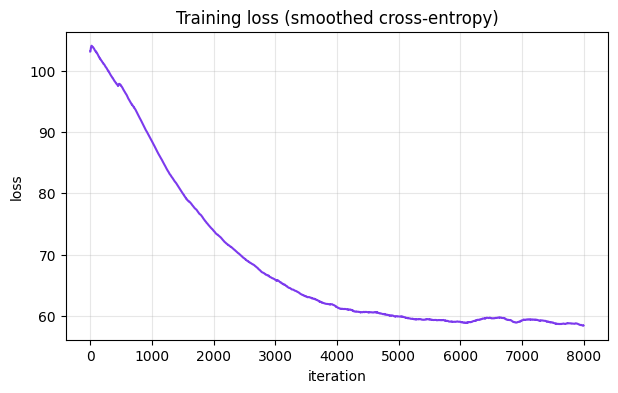

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history, color="#7c3aed")
plt.title("Training loss (smoothed cross-entropy)")
plt.xlabel("iteration"); plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.show()

In [11]:
print("AFTER training — recognisable words, names and line structure:\n")
print(decode(sample(np.zeros((hidden_size, 1)), data_ix[0], 400, params)))

AFTER training — recognisable words, names and line structure:

ir
Me co thunde,.

ARA:
Ium doghid od
Sithy grtg he nond healbt
My Mark curd tius
If hat ave hom ur ou and uren th de,
Duess My intoe tit angecollme ath Dipese aln one the o gof dit surod ch in yic cnake
Tof mnel
Hemy,

EREA:
S call afsohe percs for tabl on sard
What the thant oh you nowr nad th the thid the wou llle hot fopt wheraarthes; rit the hes romf kow,
Mhed is sence alurl afrer on me ofnet


## 8. Inspecting the forward pass: next-character predictions

After priming the network with a few characters we can read off the predicted
distribution over the next character. A trained model puts most mass on
plausible continuations.


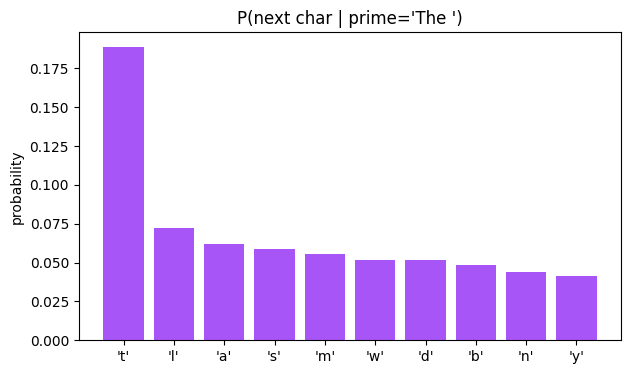

  't'   -> 0.189
  'l'   -> 0.072
  'a'   -> 0.062
  's'   -> 0.059
  'm'   -> 0.056
  'w'   -> 0.052
  'd'   -> 0.052
  'b'   -> 0.049
  'n'   -> 0.044
  'y'   -> 0.041


In [12]:
def next_char_probs(prime, p):
    h = np.zeros((hidden_size, 1))
    for ch in prime:
        x = np.zeros((vocab_size, 1)); x[stoi[ch]] = 1
        h = np.tanh(p["Wxh"] @ x + p["Whh"] @ h + p["bh"])
    return softmax(p["Why"] @ h + p["by"]).ravel()


prime = "The "
probs = next_char_probs(prime, params)
top = np.argsort(probs)[::-1][:10]

labels = [repr(itos[i]) for i in top]
plt.figure(figsize=(7, 4))
plt.bar(labels, probs[top], color="#a855f7")
plt.title(f"P(next char | prime={prime!r})")
plt.ylabel("probability")
plt.show()

for i in top:
    print(f"  {itos[i]!r:5s} -> {probs[i]:.3f}")

## 9. Vanishing gradients

BPTT multiplies the gradient by \(W_{hh}^\top\) and the \(\tanh\) slope
\((1-h^2)\le 1\) **once per step back in time**. When the dominant factor is
\(<1\) the gradient shrinks *exponentially* — distant time steps contribute
almost nothing, so a vanilla RNN struggles with long-range dependencies. (If the
factor is \(>1\) it *explodes*, which is why we clip.)

To see it cleanly, we inject a **unit gradient at the final hidden state** and
watch \(\lVert \partial L/\partial h_t \rVert\) as it propagates backward. The
behaviour is governed by the **spectral radius** \(\rho\) (largest eigenvalue
magnitude) of \(W_{hh}\):

- \(\rho < 1\) → the gradient **vanishes** exponentially (distant steps are
  forgotten),
- \(\rho > 1\) → it **explodes** (hence gradient clipping).

We build two RNNs with controlled \(\rho\) so the effect is deterministic and
independent of training, and we keep the inputs small so the \(\tanh\) slope
stays \(\approx 1\) and the \(W_{hh}\) effect is isolated.


rho=0.5: final-step norm 1.00e+01  ->  60-steps-back 2.71e-19
rho=1.15: final-step norm 1.00e+01  ->  60-steps-back 1.14e+00


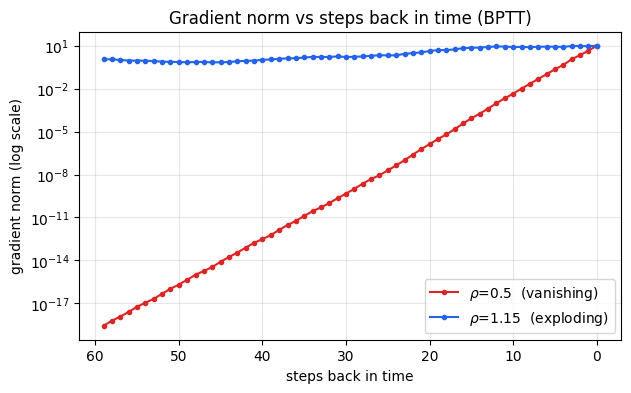

In [13]:
def gradient_through_time(inputs, p):
    """Inject a unit gradient at the last step; record ||dh_t|| going backward."""
    xs, hs = {}, {}
    hs[-1] = np.zeros((hidden_size, 1))
    for t in range(len(inputs)):
        xs[t] = np.zeros((vocab_size, 1)); xs[t][inputs[t]] = 1
        hs[t] = np.tanh(p["Wxh"] @ xs[t] + p["Whh"] @ hs[t-1] + p["bh"])

    T = len(inputs)
    dh = np.ones_like(hs[0])           # unit gradient at the final step
    norms = [0.0] * T
    for t in reversed(range(T)):
        norms[t] = float(np.linalg.norm(dh))
        dz = (1 - hs[t] ** 2) * dh
        dh = p["Whh"].T @ dz
    return norms


def make_rnn_with_spectral_radius(rho, seed=0):
    """An RNN whose Whh has a chosen spectral radius rho; small inputs keep
    tanh in its near-linear region so the Whh effect dominates."""
    rng = np.random.default_rng(seed)
    Whh = rng.standard_normal((hidden_size, hidden_size))
    Whh = Whh / np.abs(np.linalg.eigvals(Whh)).max() * rho   # rescale to rho
    return {
        "Wxh": rng.standard_normal((hidden_size, vocab_size)) * 0.1,
        "Whh": Whh,
        "Why": rng.standard_normal((vocab_size, hidden_size)) * 0.1,
        "bh":  np.zeros((hidden_size, 1)),
        "by":  np.zeros((vocab_size, 1)),
    }


T = 60
seq = data_ix[:T]
lag = np.arange(T)[::-1]               # distance from the final step

plt.figure(figsize=(7, 4))
for rho, color in [(0.5, "#dc2626"), (1.15, "#2563eb")]:
    norms = gradient_through_time(seq, make_rnn_with_spectral_radius(rho))
    regime = "vanishing" if rho < 1 else "exploding"
    plt.semilogy(lag, norms, marker="o", ms=3, color=color,
                 label=f"$\\rho$={rho}  ({regime})")
    print(f"rho={rho}: final-step norm {norms[-1]:.2e}  ->  {T}-steps-back {norms[0]:.2e}")
plt.gca().invert_xaxis()
plt.title("Gradient norm vs steps back in time (BPTT)")
plt.xlabel("steps back in time"); plt.ylabel("gradient norm (log scale)")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()

## 10. From scratch → PyTorch, and what's next

We implemented forward + BPTT by hand to understand them. In practice, libraries
do this for you. The lecture's PyTorch slide is equivalent to:

```python
import torch, torch.nn as nn

class CharRNN(nn.Module):
    def __init__(self, vocab, hidden):
        super().__init__()
        self.rnn = nn.RNN(vocab, hidden, batch_first=True)   # our Wxh, Whh, bh
        self.out = nn.Linear(hidden, vocab)                  # our Why, by

    def forward(self, x, h=None):
        out, h = self.rnn(x, h)          # autograd records the graph
        return self.out(out), h

# loss.backward()  <-- PyTorch runs BPTT for us automatically
```

`loss.backward()` performs exactly the backward pass we wrote in §4 — but
computed automatically by autograd.

### Key takeaways
- An RNN processes sequences by **reusing one cell** and a **hidden state**.
- **Forward propagation** unrolls the cell over time and accumulates loss.
- **BPTT** sums gradients across time, walking the unrolled graph backwards.
- Repeated multiplication makes gradients **vanish/explode** — motivating
  **LSTM/GRU** and gradient clipping.

### Try it yourself
1. Increase `hidden_size` or `iters` and watch the samples improve.
2. Swap the corpus for your own `.txt` file in `load_text`.
3. Replace `tanh` with the gating of an LSTM and compare the vanishing-gradient plot.
